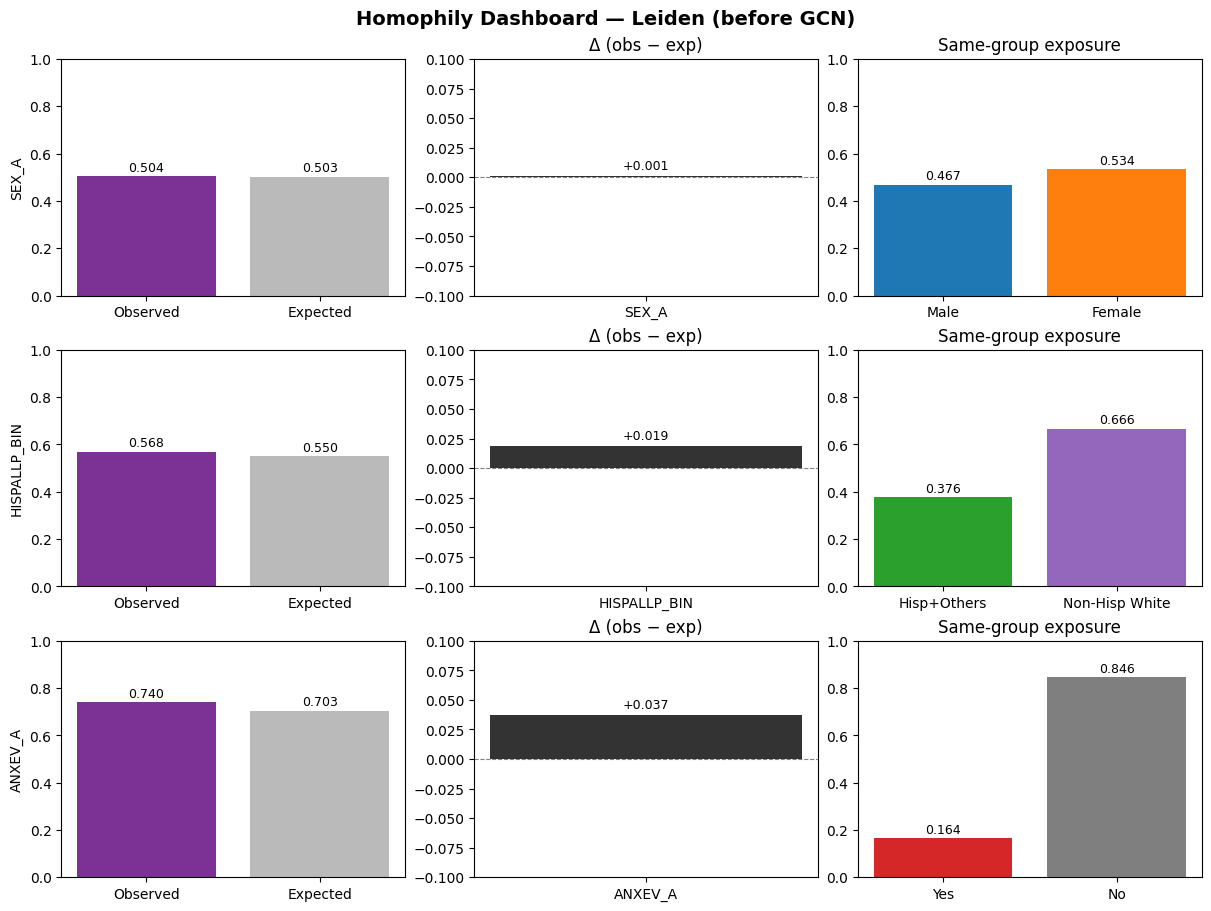

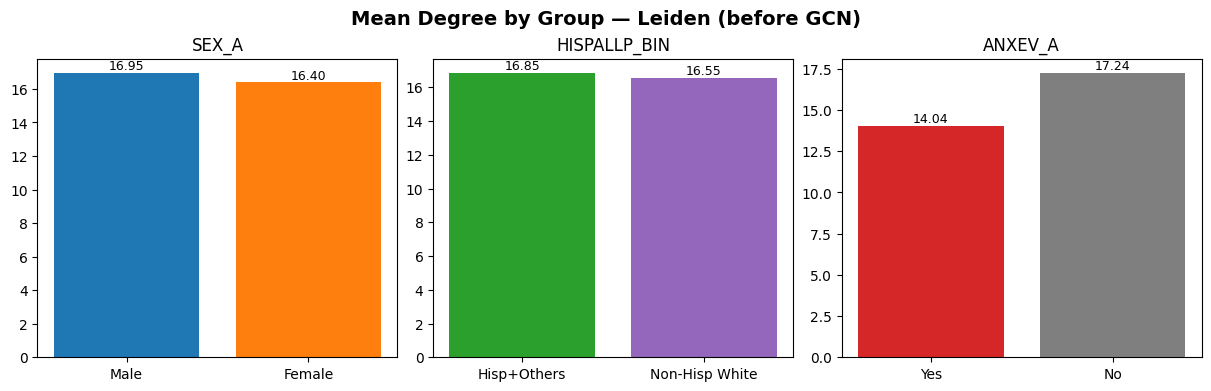

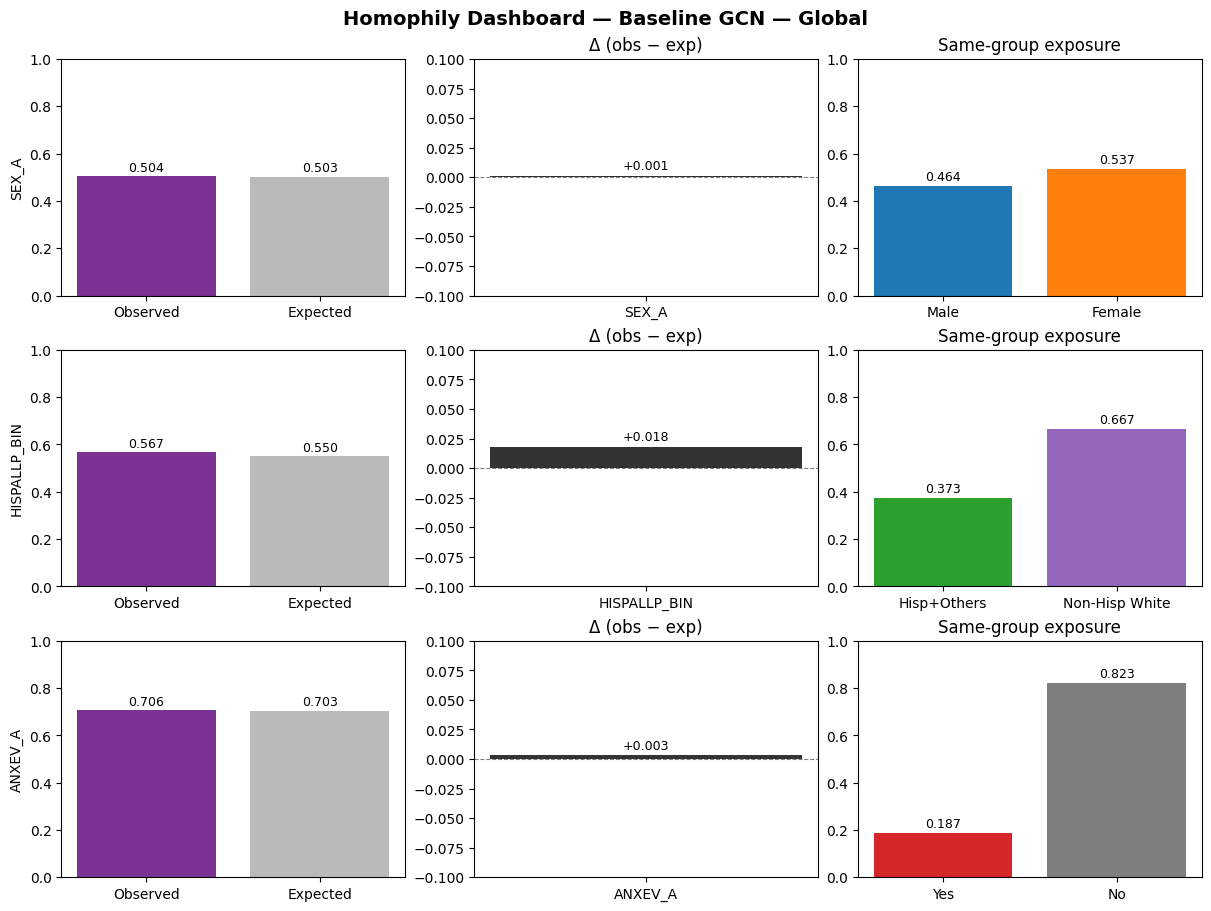

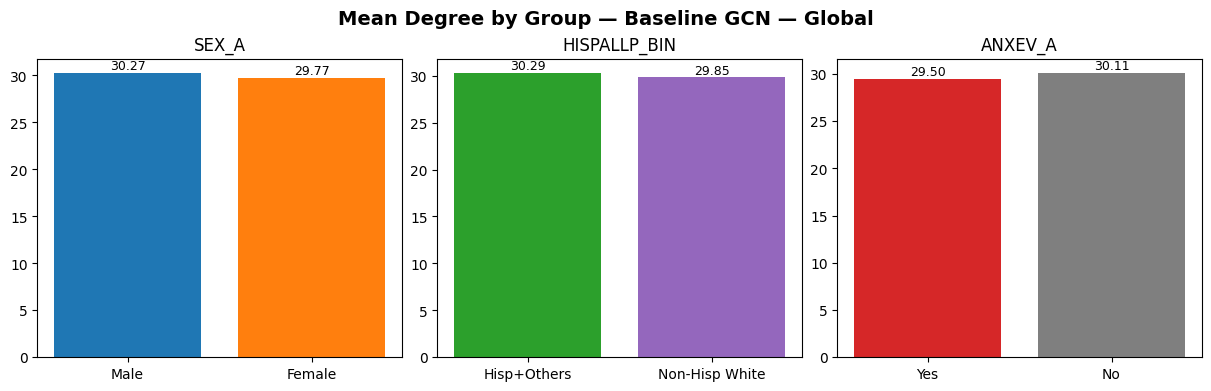

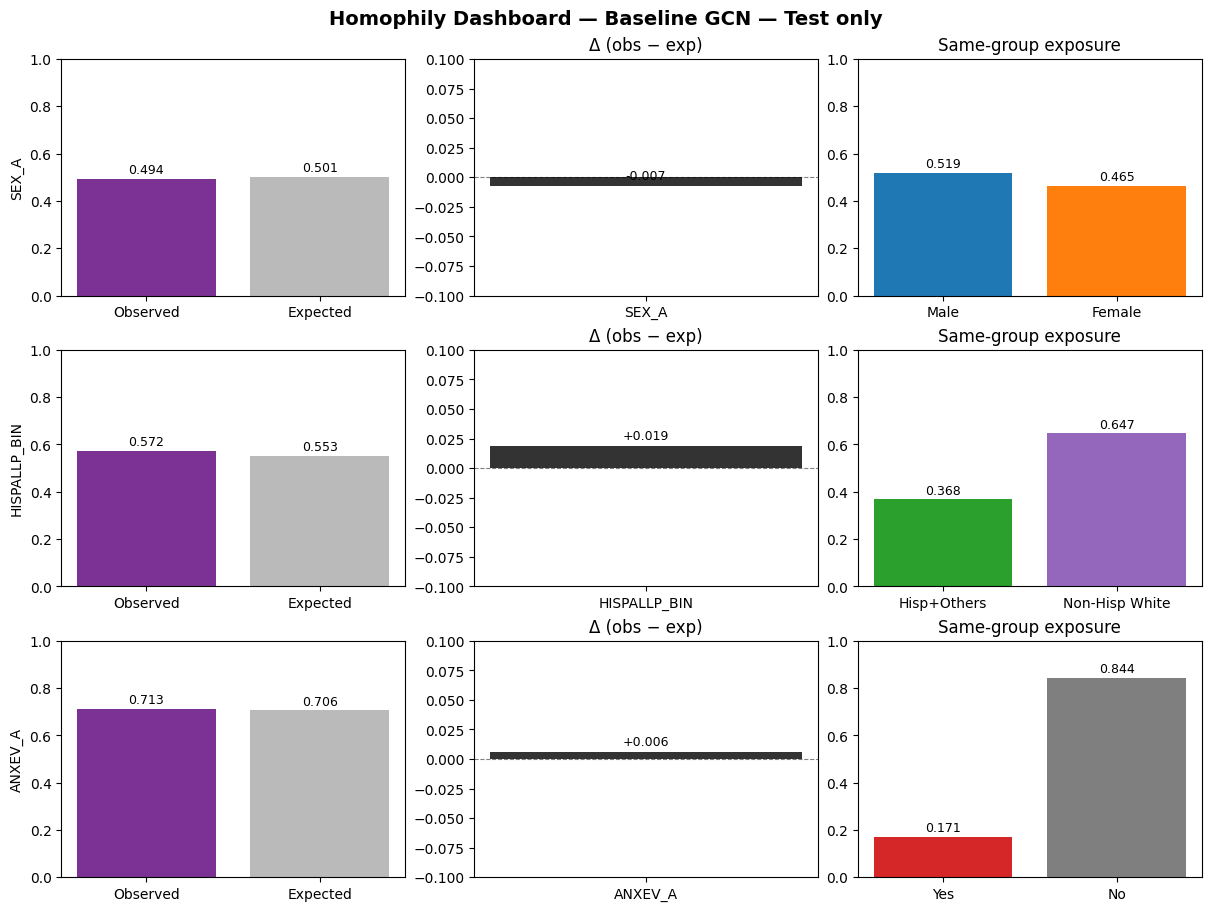

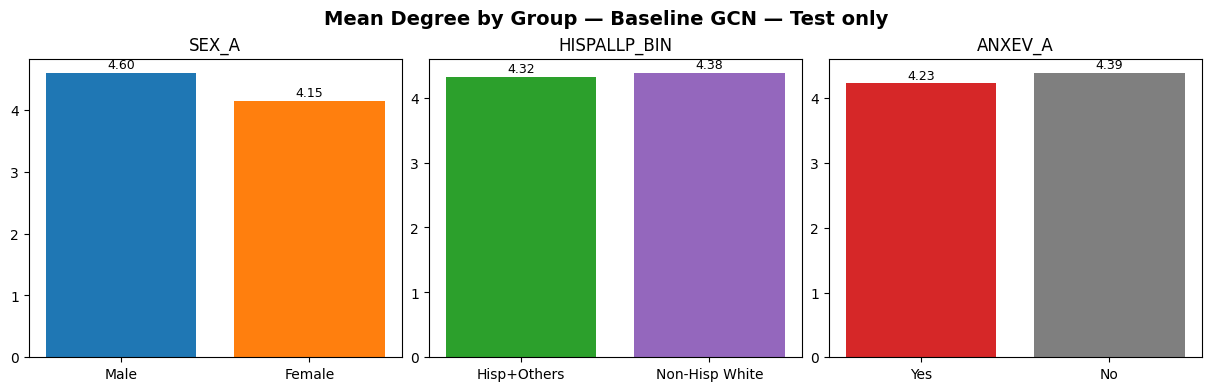

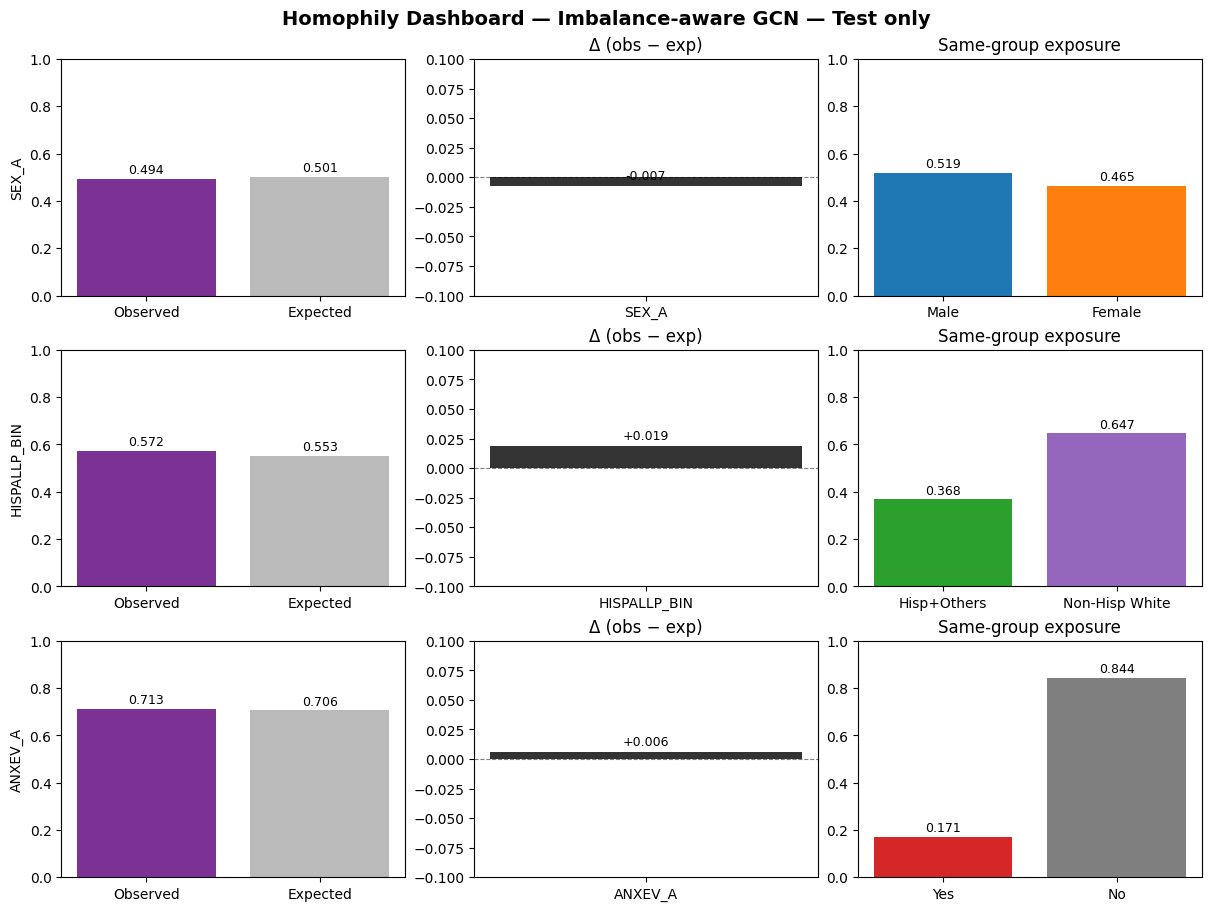

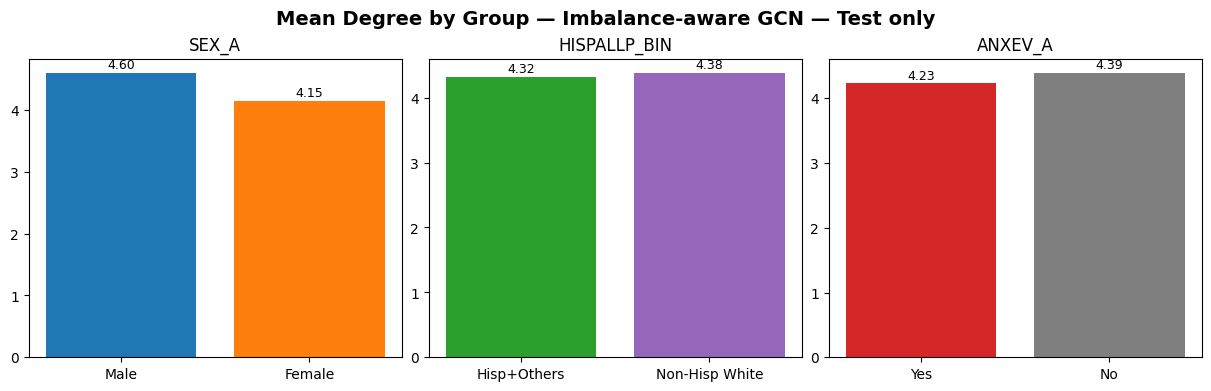

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# 1) Results
SCENARIOS = {
    "Leiden (before GCN)": {
        "observed": {"SEX":0.504, "HISP":0.568, "ANX":0.740},
        "expected": {"SEX":0.503, "HISP":0.550, "ANX":0.703},
        "delta":    {"SEX":+0.001,"HISP":+0.019,"ANX":+0.037},
        "mean_degree": {
            "SEX":{"labels":["Male","Female"], "values":[16.95,16.40]},
            "HISP":{"labels":["Hisp+Others","Non-Hisp White"], "values":[16.85,16.55]},
            "ANX":{"labels":["Yes","No"], "values":[14.04,17.24]},
        },
        "exposure": {
            "SEX":{"labels":["Male","Female"], "values":[0.467,0.534]},
            "HISP":{"labels":["Hisp+Others","Non-Hisp White"], "values":[0.376,0.666]},
            "ANX":{"labels":["Yes","No"], "values":[0.164,0.846]},
        },
    },
    "Baseline GCN — Global": {
        "observed": {"SEX":0.504, "HISP":0.567, "ANX":0.706},
        "expected": {"SEX":0.503, "HISP":0.550, "ANX":0.703},
        "delta":    {"SEX":+0.001,"HISP":+0.018,"ANX":+0.003},
        "mean_degree": {
            "SEX":{"labels":["Male","Female"], "values":[30.27,29.77]},
            "HISP":{"labels":["Hisp+Others","Non-Hisp White"], "values":[30.29,29.85]},
            "ANX":{"labels":["Yes","No"], "values":[29.50,30.11]},
        },
        "exposure": {
            "SEX":{"labels":["Male","Female"], "values":[0.464,0.537]},
            "HISP":{"labels":["Hisp+Others","Non-Hisp White"], "values":[0.373,0.667]},
            "ANX":{"labels":["Yes","No"], "values":[0.187,0.823]},
        },
    },
    "Baseline GCN — Test only": {
        "observed": {"SEX":0.494, "HISP":0.572, "ANX":0.713},
        "expected": {"SEX":0.501, "HISP":0.553, "ANX":0.706},
        "delta":    {"SEX":-0.007,"HISP":+0.019,"ANX":+0.006},
        "mean_degree": {
            "SEX":{"labels":["Male","Female"], "values":[4.60,4.15]},
            "HISP":{"labels":["Hisp+Others","Non-Hisp White"], "values":[4.32,4.38]},
            "ANX":{"labels":["Yes","No"], "values":[4.23,4.39]},
        },
        "exposure": {
            "SEX":{"labels":["Male","Female"], "values":[0.519,0.465]},
            "HISP":{"labels":["Hisp+Others","Non-Hisp White"], "values":[0.368,0.647]},
            "ANX":{"labels":["Yes","No"], "values":[0.171,0.844]},
        },
    },
    "Imbalance-aware GCN — Test only": {
        "observed": {"SEX":0.494, "HISP":0.572, "ANX":0.713},
        "expected": {"SEX":0.501, "HISP":0.553, "ANX":0.706},
        "delta":    {"SEX":-0.007,"HISP":+0.019,"ANX":+0.006},
        "mean_degree": {
            "SEX":{"labels":["Male","Female"], "values":[4.60,4.15]},
            "HISP":{"labels":["Hisp+Others","Non-Hisp White"], "values":[4.32,4.38]},
            "ANX":{"labels":["Yes","No"], "values":[4.23,4.39]},
        },
        "exposure": {
            "SEX":{"labels":["Male","Female"], "values":[0.519,0.465]},
            "HISP":{"labels":["Hisp+Others","Non-Hisp White"], "values":[0.368,0.647]},
            "ANX":{"labels":["Yes","No"], "values":[0.171,0.844]},
        },
    },
}

# Plot helpers 
ATTR_ORDER = ["SEX", "HISP", "ANX"]
ATTR_TITLES= {"SEX":"SEX_A", "HISP":"HISPALLP_BIN", "ANX":"ANXEV_A"}

OBS_EXP_COLORS = ["#7b3294","#bababa"]    # purple / gray
GROUP_COLORS   = {
    "SEX":  ["#1f77b4","#ff7f0e"],       # blue / orange
    "HISP": ["#2ca02c","#9467bd"],       # green / purple
    "ANX":  ["#d62728","#7f7f7f"],       # red / gray
}

def annotate_bars(ax, fmt="{:.3f}", dy=0.01):
    for p in ax.patches:
        h = p.get_height()
        if np.isfinite(h):
            ax.text(p.get_x()+p.get_width()/2, h+dy, fmt.format(h),
                    ha="center", va="bottom", fontsize=9)

def plot_dashboard(scn_name, scn):
    fig, axes = plt.subplots(3, 3, figsize=(12, 9), constrained_layout=True)
    fig.suptitle(f"Homophily Dashboard — {scn_name}", fontsize=14, weight="bold")

    for r, key in enumerate(ATTR_ORDER):
        # 1) Observed vs Expected
        ax = axes[r, 0]
        obs = scn["observed"][key]; exp = scn["expected"][key]
        ax.bar(["Observed","Expected"], [obs, exp], color=OBS_EXP_COLORS)
        ax.set_ylim(0, 1); ax.set_ylabel(ATTR_TITLES[key])
        annotate_bars(ax)

        # 2) Δ (Observed − Expected)
        ax = axes[r, 1]
        delta = scn["delta"][key]
        ax.axhline(0, color="k", lw=0.8, ls="--", alpha=0.5)
        ax.bar([ATTR_TITLES[key]], [delta], color="#333333")
        ax.set_ylim(-0.1, 0.1)
        annotate_bars(ax, fmt="{:+.3f}", dy=0.003)
        ax.set_title("Δ (obs − exp)")

        # 3) Same-group exposure (by group)
        ax = axes[r, 2]
        lab = scn["exposure"][key]["labels"]
        val = scn["exposure"][key]["values"]
        ax.bar(lab, val, color=GROUP_COLORS[key])
        ax.set_ylim(0, 1); annotate_bars(ax)
        ax.set_title("Same-group exposure")

    plt.show()

def plot_mean_degree(scn_name, scn):
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), constrained_layout=True)
    fig.suptitle(f"Mean Degree by Group — {scn_name}", fontsize=14, weight="bold")
    for i, key in enumerate(ATTR_ORDER):
        lab = scn["mean_degree"][key]["labels"]
        val = scn["mean_degree"][key]["values"]
        ax = axes[i]
        ax.bar(lab, val, color=GROUP_COLORS[key])
        ax.set_title(ATTR_TITLES[key])
        annotate_bars(ax, fmt="{:.2f}", dy=0.02)
    plt.show()

# ====== 3) Draw all scenarios ======
for name, block in SCENARIOS.items():
    plot_dashboard(name, block)
    plot_mean_degree(name, block)


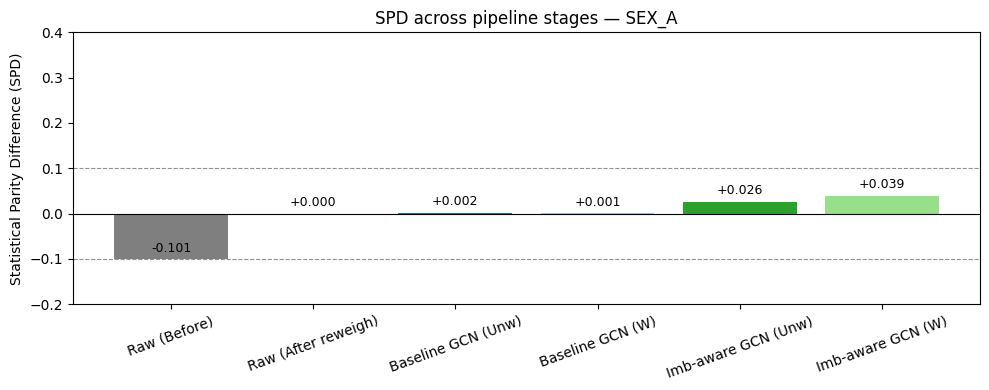

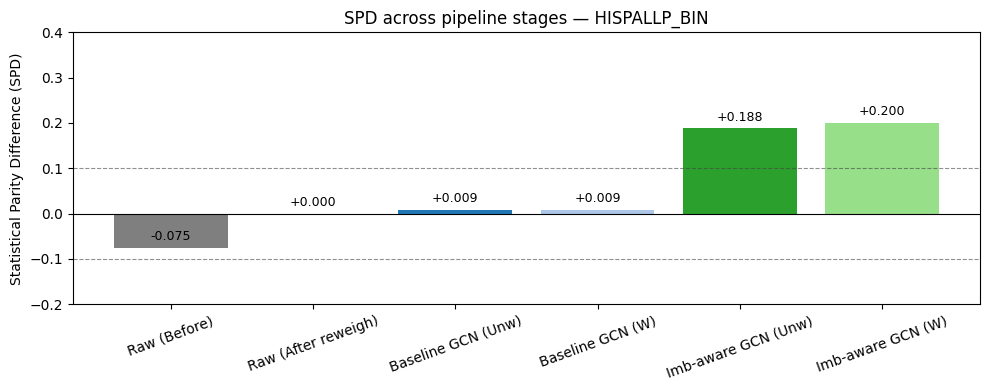

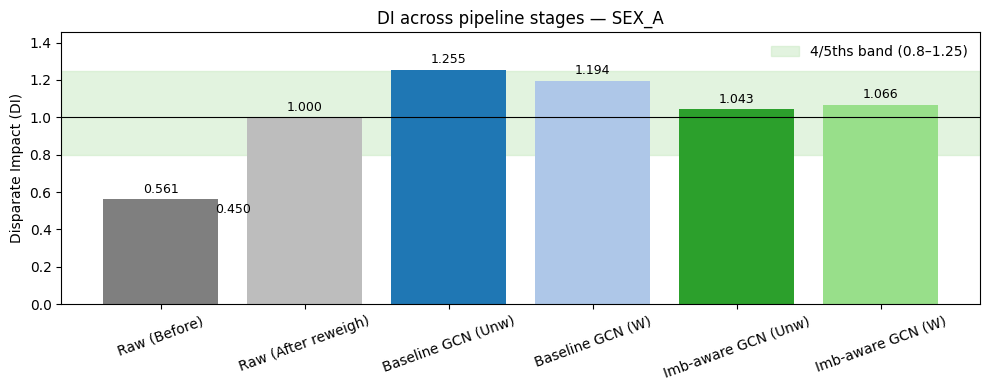

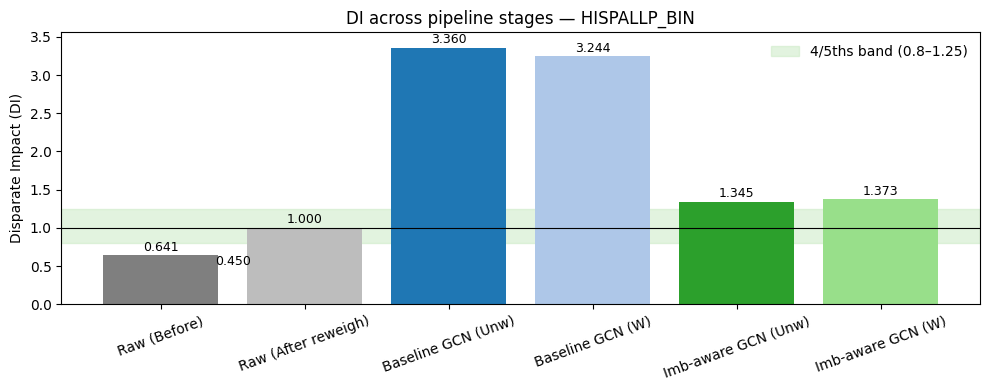

In [2]:
import numpy as np
import matplotlib.pyplot as plt

#  Data
USE_CORRECTED_HISP_SPD_W = True  # True -> SPD_w(HISP)=0.200, False -> use 1.066 from table (not valid)

stages = [
    "Raw (Before)",
    "Raw (After reweigh)",
    "Baseline GCN (Unw)",
    "Baseline GCN (W)",
    "Imb-aware GCN (Unw)",
    "Imb-aware GCN (W)",
]

# SPD by attribute and stage
SPD = {
    "SEX_A": {
        "Raw (Before)":         -0.1010,
        "Raw (After reweigh)":   0.0,
        "Baseline GCN (Unw)":    0.002,
        "Baseline GCN (W)":      0.001,
        "Imb-aware GCN (Unw)":   0.026,
        "Imb-aware GCN (W)":     0.039,
    },
    "HISPALLP_BIN": {
        "Raw (Before)":         -0.0752,
        "Raw (After reweigh)":   0.0,
        "Baseline GCN (Unw)":    0.009,
        "Baseline GCN (W)":      0.009,
        "Imb-aware GCN (Unw)":   0.188,
        "Imb-aware GCN (W)":     (0.200 if USE_CORRECTED_HISP_SPD_W else 1.066),  # see note above
    },
}

# DI by attribute and stage
DI = {
    "SEX_A": {
        "Raw (Before)":          0.5613,
        "Raw (After reweigh)":   1.0000,
        "Baseline GCN (Unw)":    1.255,
        "Baseline GCN (W)":      1.194,
        "Imb-aware GCN (Unw)":   1.043,
        "Imb-aware GCN (W)":     1.066,
    },
    "HISPALLP_BIN": {
        "Raw (Before)":          0.6413,
        "Raw (After reweigh)":   1.0000,
        "Baseline GCN (Unw)":    3.360,
        "Baseline GCN (W)":      3.244,
        "Imb-aware GCN (Unw)":   1.345,
        "Imb-aware GCN (W)":     1.373,
    },
}

#  Styling helpers 
def stage_colors(n=6):
    # three blocks: raw (gray), baseline (blue tones), imbalance-aware (green tones)
    return ["#7f7f7f", "#bdbdbd", "#1f77b4", "#aec7e8", "#2ca02c", "#98df8a"][:n]

def annotate(ax, fmt="{:.3f}", dy=0.01, rotation=0):
    for p in ax.patches:
        h = p.get_height()
        if np.isfinite(h):
            ax.text(p.get_x()+p.get_width()/2, h + dy, fmt.format(h),
                    ha="center", va="bottom", fontsize=9, rotation=rotation)

#  Figure 1: SPD (by stage) 
for attr in ["SEX_A", "HISPALLP_BIN"]:
    vals = [SPD[attr][s] for s in stages]
    colors = stage_colors(len(stages))

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(stages, vals, color=colors)
    ax.axhline(0, color="k", lw=0.8)
    # optional guideline band for "near parity" (rule-of-thumb)
    ax.axhline(+0.10, color="#444", lw=0.8, ls="--", alpha=0.6)
    ax.axhline(-0.10, color="#444", lw=0.8, ls="--", alpha=0.6)
    ax.set_ylabel("Statistical Parity Difference (SPD)")
    ax.set_title(f"SPD across pipeline stages — {attr}")
    ax.set_ylim(min(-0.2, min(vals)-0.05), max(0.4, max(vals)+0.05))
    ax.tick_params(axis='x', rotation=20)
    annotate(ax, fmt="{:+.3f}", dy=0.01)
    plt.tight_layout()
    plt.show()

#  Figure 2: DI (by stage) 
for attr in ["SEX_A", "HISPALLP_BIN"]:
    vals = [DI[attr][s] for s in stages]
    colors = stage_colors(len(stages))

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(stages, vals, color=colors)
    # 4/5ths rule band (0.8–1.25)
    ax.axhspan(0.8, 1.25, color="#c7e9c0", alpha=0.5, zorder=0, label="4/5ths band (0.8–1.25)")
    ax.axhline(1.0, color="k", lw=0.8)
    ax.set_ylabel("Disparate Impact (DI)")
    ax.set_title(f"DI across pipeline stages — {attr}")
    ymax = max(1.4, max(vals) + 0.2)
    ax.set_ylim(0, ymax)
    ax.tick_params(axis='x', rotation=20)
    annotate(ax, fmt="{:.3f}", dy=0.02)
    ax.legend(loc="upper right", frameon=False)
    plt.tight_layout()
    plt.show()

#Optional sanity check 
# Warn if any SPD is outside [-1, 1]
for attr in SPD:
    for s, v in SPD[attr].items():
        if not (-1.0 <= v <= 1.0):
            print(f"[WARN] SPD out of bounds for {attr} @ {s}: {v} (check your numbers)")


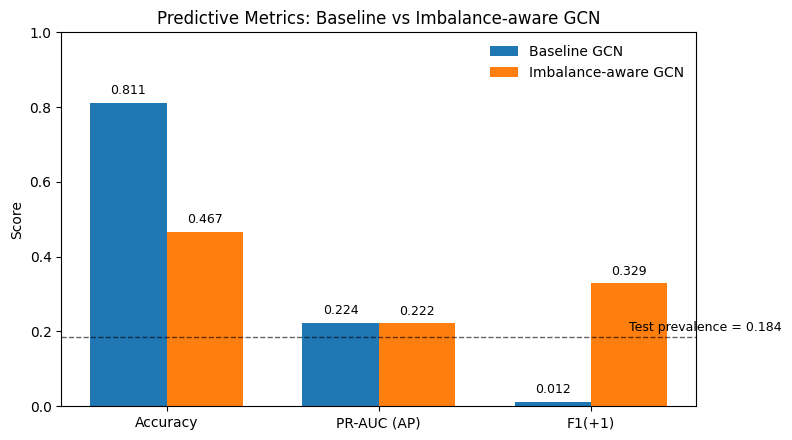

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ---- data ----
metrics   = ["Accuracy", "PR-AUC (AP)", "F1(+1)"]
baseline  = [0.811, 0.224, 0.012]
imbaware  = [0.467, 0.222, 0.329]
prev_test = 0.184  # positive prevalence in TEST

x = np.arange(len(metrics))
w = 0.36

fig, ax = plt.subplots(figsize=(8,4.5))

b1 = ax.bar(x - w/2, baseline,  width=w, label="Baseline GCN")
b2 = ax.bar(x + w/2, imbaware,  width=w, label="Imbalance-aware GCN")

# prevalence reference (useful for reading PR-AUC)
ax.axhline(prev_test, linestyle="--", linewidth=1.0, color="k", alpha=0.6)
ax.text(len(metrics)-0.1, prev_test+0.01, f"Test prevalence = {prev_test:.3f}",
        ha="right", va="bottom", fontsize=9)

ax.set_xticks(x, metrics)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Score")
ax.set_title("Predictive Metrics: Baseline vs Imbalance-aware GCN")
ax.legend(frameon=False)

# value labels
def annotate(bars):
    for p in bars:
        h = p.get_height()
        ax.text(p.get_x()+p.get_width()/2, h+0.015, f"{h:.3f}",
                ha="center", va="bottom", fontsize=9)
annotate(b1); annotate(b2)

plt.tight_layout()
plt.show()
